In [ ]:
%pip install pykan==0.2.8

Usando dispositivo: cpu
checkpoint directory created: ./checkpoints_exp
saving model version 0.0


| train_loss: 9.54e-03 | test_loss: 9.46e-03 | reg: 6.47e+00 | : 100%|█| 50/50 [00:29<00:00,  1.69it


saving model version 0.1


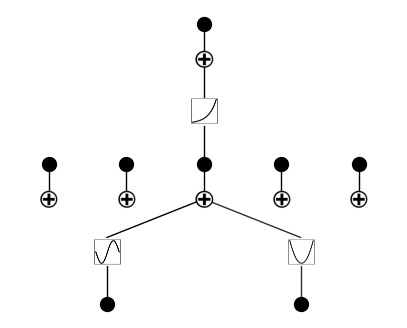

In [ ]:
from kan import *
import torch
import matplotlib.pyplot as plt

# 1. Configuración del dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# 2. Definición de la función objetivo: f(x,y) = exp(sin(pi*x) + y^2)
def f_target(x):
    x1 = x[:, [0]]
    x2 = x[:, [1]]
    return torch.exp(torch.sin(torch.pi * x1) + x2**2)

# 3. Creación del dataset
dataset = create_dataset(
    f_target,
    n_var=2,
    train_num=3000,
    test_num=1000,
    device=device
)

# 4. Inicialización del modelo KAN
model = KAN(
    width=[2, 5, 1],
    grid=5,
    k=3,
    seed=1,
    device=device,
    ckpt_path="./checkpoints_exp"
)

# 5. Entrenamiento del modelo
results = model.fit(
    dataset,
    opt="LBFGS",
    steps=50,
    lamb=0.001
)

# 6. Visualización del modelo entrenado
model.plot()
plt.show()

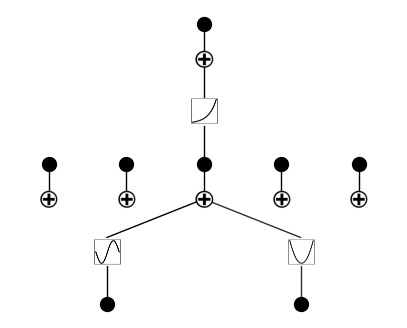

saving model version 0.2


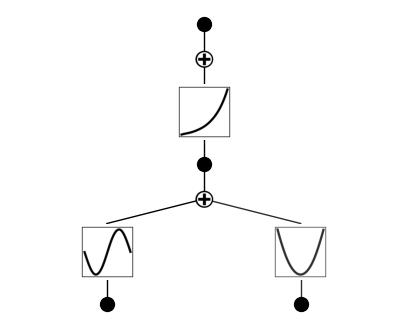

original
layer 0
Parameter containing:
tensor([[0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.]])
layer 1
Parameter containing:
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [0.]])
podado
layer 0
Parameter containing:
tensor([[1.],
        [1.]])
layer 1
Parameter containing:
tensor([[1.]])


MultKAN(
  (act_fun): ModuleList(
    (0-1): 2 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-1): 2 x Symbolic_KANLayer()
  )
)

In [ ]:
model_podado = model.prune()
model_podado.plt()
plt.show()